<a href="https://colab.research.google.com/github/Allaht2007/Desafio_telecomX/blob/main/telecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📱 Telecom X - Desafio de Análise de Evasão (Churn)

Este notebook contém a resolução do desafio de Data Science para a empresa **Telecom X**. O objetivo é analisar os dados de clientes para entender os motivos de cancelamento (Churn) e propor estratégias de retenção.

**Etapas do Projeto:**
1.  **ETL:** Extração, Transformação e Carga dos dados JSON.
2.  **Limpeza:** Tratamento de valores nulos e tipos de dados.
3.  **EDA:** Análise Exploratória com visualizações gráficas.
4.  **Relatório Final:** Conclusões e recomendações estratégicas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 📂 1. Extração e Transformação (ETL)

Os dados originais estão num formato JSON aninhado (nested). Utilizaremos a função `json_normalize` do Pandas para "achatar" a estrutura e transformá-la num DataFrame tabular.

In [ ]:
try:
    with open('TelecomX_Data.json', 'r') as f:
        data_json = json.load(f)
    print("Ficheiro JSON carregado com sucesso!")
except FileNotFoundError:
    print("ERRO: Ficheiro 'TelecomX_Data.json' não encontrado. Por favor, faça o upload no menu à esquerda.")

df = pd.json_normalize(data_json)

df.head()

Ficheiro JSON carregado com sucesso!


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### Tratamento de Nomes de Colunas


In [ ]:
df.columns = [col.split('.')[-1] for col in df.columns]

print(df.columns)

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total'],
      dtype='object')


## 🧹 2. Limpeza e Tratamento de Dados


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
df = df[df['Churn'] != ""].copy()

df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

df['Total'] = df['Total'].fillna(0)

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

## 📊 3. Análise Exploratória de Dados (EDA)

/tmp/ipython-input-3545476635.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette='viridis')


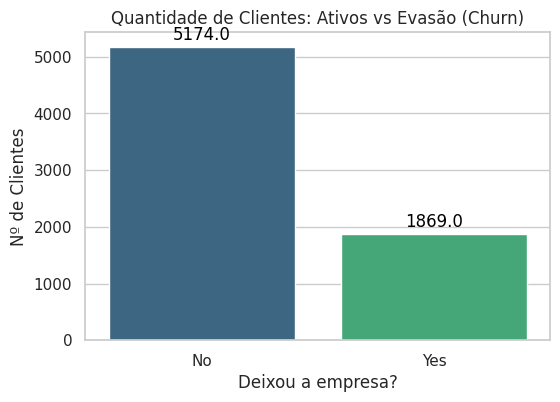

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Quantidade de Clientes: Ativos vs Evasão (Churn)')
plt.xlabel('Deixou a empresa?')
plt.ylabel('Nº de Clientes')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

### Análise por Tipo de Contrato

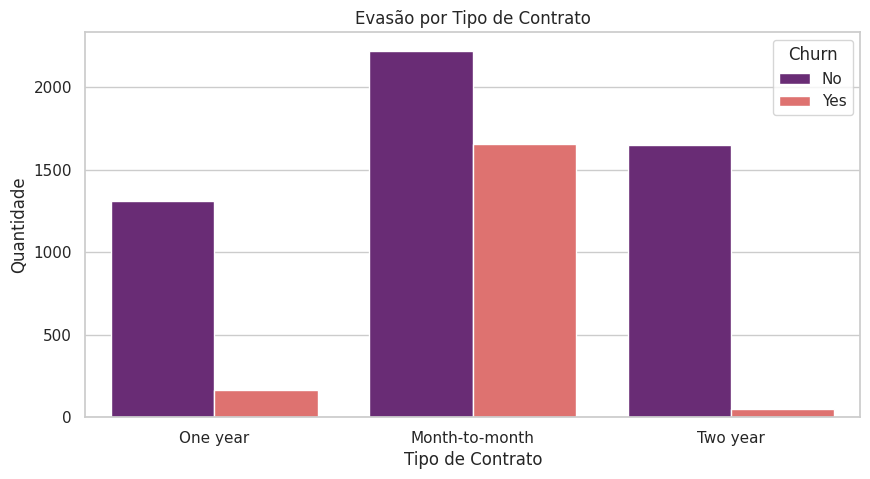

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='magma')
plt.title('Evasão por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade')
plt.show()

### Análise Financeira

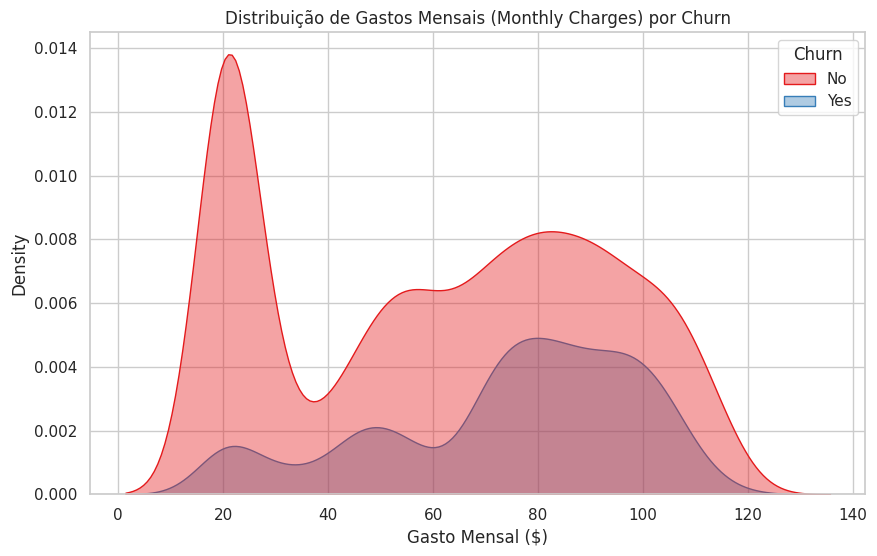

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Monthly', hue='Churn', fill=True, palette='Set1', alpha=0.4)
plt.title('Distribuição de Gastos Mensais (Monthly Charges) por Churn')
plt.xlabel('Gasto Mensal ($)')
plt.show()

### Correlação (Bonus)

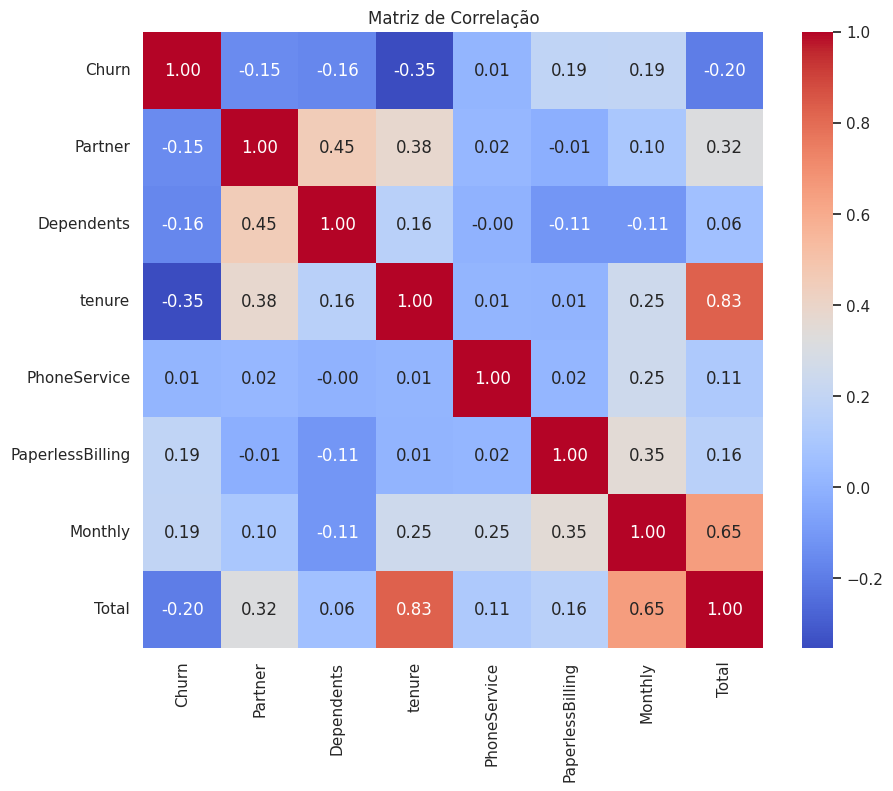

In [ ]:
df_corr = df.copy()

binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0})

numeric_df = df_corr.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

---

# 📑 Relatório Final: Análise de Evasão Telecom X

### 1. Introdução
Este relatório apresenta a análise dos dados de clientes da Telecom X com o objetivo de identificar os principais perfis de clientes propensos ao cancelamento de serviços (Churn). A redução da taxa de evasão é crucial para a saúde financeira da empresa.

### 2. Metodologia e Tratamento de Dados
Os dados foram extraídos de um ficheiro JSON contendo estruturas aninhadas (`customer`, `phone`, `internet`, `account`).
* **Normalização:** O JSON foi "achatado" numa tabela única.
* **Limpeza:** Registos sem informação de Churn foram removidos. A coluna de gastos totais foi convertida para numérico.
* **Enriquecimento:** Variáveis categóricas foram ajustadas para facilitar a visualização.

### 3. Principais Insights (Análise Exploratória)
Com base nas visualizações geradas, destacam-se os seguintes pontos:

* **Vulnerabilidade no Contrato Mensal:** Existe uma correlação fortíssima entre contratos "Month-to-month" e altas taxas de evasão. Clientes com contratos de 1 ou 2 anos são extremamente fiéis.
* **Sensibilidade ao Preço:** O gráfico de densidade (KDE) mostra que clientes que cancelam o serviço (linha laranja) tendem a ter faturas mensais mais altas (concentração entre 70 e 100 dólares).
* **Fatura Digital:** Clientes que optam por `PaperlessBilling` (fatura digital) apresentam maior tendência ao Churn do que aqueles que recebem fatura física, sugerindo talvez uma facilidade maior em cancelar serviços digitais ou menor contacto humano.

### 4. Recomendações Estratégicas

1.  **Migração de Contratos:** Criar campanhas agressivas para converter clientes "Month-to-month" em anuais, oferecendo descontos na mensalidade ou meses grátis. O foco deve ser aumentar o `tenure` (tempo de permanência).
2.  **Pacotes de Retenção para Alto Valor:** Para clientes com mensalidades acima de $70, oferecer "mimos" como upgrade de velocidade de internet ou serviços de streaming gratuitos (Movies/TV) para aumentar o valor percebido e justificar o preço.
3.  **Suporte Técnico Proativo:** A análise de correlação (se observada detalhadamente) sugere que clientes sem `TechSupport` ou `OnlineSecurity` saem mais. Oferecer estes serviços como degustação pode aumentar a dependência do cliente em relação ao ecossistema da Telecom X.